<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">
   

In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Linux 6.17.0-23-generic
  Architecture  : x86_64
  Python        : 3.12.8
------------------------------------------------------------
  Core          : hoops-ai             1.1.0
  CAD Access    : hoops-exchange       26.2.0.dev7  (build: 1e11169 2026-03-23T17:47:19Z)
  Conversion    : hoops-converter      26.1.0.dev7  (build: 36742b6 2026-03-23T17:49:37Z)
  Insights      : hoops-web-viewer     26.1.0.dev5  (build: 25137b2 2026-03-23T13:36:51Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


In [2]:
import pathlib, sys
sys.path.insert(0, str( pathlib.Path.cwd()))
import importlib
from scripts import helper_tutorials  
importlib.reload(helper_tutorials)  # Forces reload of the latest version

<module 'scripts.helper_tutorials' from '/home/maxime.marechal/Projects/HAI-Tutorials/notebooks/scripts/helper_tutorials.py'>

# HOOPS AI: Using a Pre-trained Model

In this tutorial, we use a pre-trained model to detect manufacturing features. The model was trained with HOOPS AI using the pre-built `GraphNodeClassification` architecture. The dataset contained more than 160,000 CAD files, split as follows:

Train set contains          : 113878 samples (70.12%)
Validation set contains     : 24220 samples (14.91%)
Test set contains           : 24311 samples (14.97%)
Total samples               : 162409

The model reported an IoU (intersection-over-union) score of 98.9% on the test set.

The training data combines synthetic samples describing machining features from the CADSynth dataset and instance-labeled machining-feature samples from the MFInstSeg dataset. Both datasets are public.

<div style="display: flex; gap: 10px;">
  <img src="../images/features_sampling_dataset.png" style="width: 50%;">
  <img src="../images/features_intersection_dataset.png" style="width: 50%;">
</div>

The model was then tested on unseen real-part samples. It was able to detect some features in real cases, showing that beyond the simplified training data, the model learned how to detect the features.

## Dataset Citations

This notebook relies on a model trained with data derived from the following public datasets.

**CADSynth**
Zhang, Shuming (2024). *CADSynth: 100,000 solid models in STEP format with labels in JSON format*. V1. Science Data Bank. https://doi.org/10.57760/sciencedb.17011

Dataset page: https://www.scidb.cn/en/detail?dataSetId=931c088fd44f4d3e82891a5180f10d90

**MFInstSeg**
*MFInstSeg: 62,495 solid models in STEP format with instance labels in JSON format*. Baidu AI Studio dataset page. https://aistudio.baidu.com/datasetdetail/211864?lang=en.

Use this dataset page citation when referencing the MFInstSeg data source in these tutorial materials.

In [3]:

import pathlib
import json

# Define paths 
demofile_dir  = pathlib.Path.cwd().parent.joinpath("packages", "cadfiles")
output_dir    = pathlib.Path.cwd().joinpath("out")
output_dir.mkdir(parents=True, exist_ok=True)  # Required by hoops_viewer StaticFiles mount
cad_file_test = str(demofile_dir.joinpath("nist_ftc_06_asme1_rd_sw1802.SLDPRT")) # largest_mftrcad.step
#cad_file_test = str(demofile_dir.joinpath("largest_mftrcad.step")) # 


In [4]:
from hoops_ai.cadaccess import HOOPSLoader
from hoops_ai.insights import CADViewer

# Initialize CAD loader (needed for ML inference later)
loader = HOOPSLoader()

# Create viewer and load CAD file (auto-converts to SCS and displays in sidecar)
viewer = CADViewer(display_mode='sidecar', silent=True, static_folder=output_dir)
viewer.load_cad_file(cad_file_test, auto_convert=True, white_background=True)



True

In [5]:
viewer.show()

# ML prediction 

The `FlowInference` class handles inference with trained models. It provides methods for preprocessing CAD data, making predictions, and post-processing results.

## Transform the CAD data into machine-learning input data

- Load the trained model from the checkpoint file and instantiate it with the appropriate `FlowModel`
- Initialize `HOOPSLoader` to read the CAD file
- Preprocess the CAD file to encode its data according to the expected ML architecture

In [6]:
from hoops_ai.ml.EXPERIMENTAL import FlowInference
from hoops_ai.ml.EXPERIMENTAL import GraphNodeClassification

trained_model = pathlib.Path.cwd().parent.joinpath("packages","trained_ml_models", "ts3d_162k_mfr.ckpt")

inference_model = FlowInference(cad_loader = loader, flowmodel = GraphNodeClassification(result_dir=output_dir))
inference_model.load_from_checkpoint(trained_model)

INFO:Lightning automatically upgraded your loaded checkpoint from v1.7.2 to v2.5.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../packages/trained_ml_models/ts3d_162k_mfr.ckpt`


Successfully loaded model from checkpoint: /home/maxime.marechal/Projects/HAI-Tutorials/packages/trained_ml_models/ts3d_162k_mfr.ckpt


For the inference test, we use a file from the NIST list.

In [7]:
ml_input = inference_model.preprocess(cad_file_test)    
predictions, probabilities = inference_model.predict_and_postprocess(ml_input)
print(predictions)


[ 0  0 22  0 22  0  0  0 22 22 22  0  0  0 22 22 22  0  0 17  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 17  0  0 17  0
  1  2  2  1  1 17 23 23 17 23 23 17 23 23 17 23 23  0  0 22  0 22 23 23
 23  0 17 23 23 23  2  1  2  1  3 16 16 16 16 16 21 21 16  0 16 16 24 24
 24 24 24 24  0  0  0  0 24  0 16  0  0  0 21 21 21 21 21 21 21 21 12 12
 12 12 12 21 21 21 21 21 21 21 21 21 21 21 21 21 21 12 21 21 21 21 21 21]


# Visualize Predictions on CAD Model

Now that we have predictions for each face, we'll use the **HOOPS AI Insights** module to visualize them on the 3D model.

## Step 1: Create a Color Palette

We use `ColorPalette` to map each manufacturing feature label to a unique color and description. We can optionally reserve specific colors for important features (e.g., red for through holes).


In [8]:
from hoops_ai.insights.utils import ColorPalette

# Define label descriptions
labels_description = {
    0: "no-label", 1: "rectangular_through_slot", 2: "triangular_through_slot", 3: "rectangular_passage",
    4: "triangular_passage", 5: "6sides_passage", 6: "rectangular_through_step", 7: "2sides_through_step",
    8: "slanted_through_step", 9: "rectangular_blind_step", 10: "triangular_blind_step", 
    11: "rectangular_blind_slot", 12: "rectangular_pocket", 13: "triangular_pocket", 14: "6sides_pocket",
    15: "chamfer", 16: "circular through slot", 17: "through hole", 18: "circular blind step",
    19: "horizontal circular end blind slot", 20: "vertical circular end blind slot", 
    21: "circular end pocket", 22: "o-ring", 23: "blind hole", 24: "fillet"
}

# Create color palette with maximally distinct colors (use_distinct_colors=True by default)
color_palette = ColorPalette.from_labels(
    labels_description,
    reserved_colors={
        0: (200, 200, 200),  # Gray for background
    }
)

print(f"Created color palette for {len(color_palette)} labels")
print(f"Sample: Label 17 -> Color {color_palette.get_color(17)}, Description: '{color_palette.get_description(17)}'")
print(f"Sample: Label 22 -> Color {color_palette.get_color(22)}, Description: '{color_palette.get_description(22)}'")
print(f"Sample: Label 23 -> Color {color_palette.get_color(23)}, Description: '{color_palette.get_description(23)}'")
#help(ColorPalette)

Created color palette for 25 labels
Sample: Label 17 -> Color (89, 51, 21), Description: 'through hole'
Sample: Label 22 -> Color (24, 87, 242), Description: 'o-ring'
Sample: Label 23 -> Color (135, 191, 57), Description: 'blind hole'


### Understanding the Workflow

The visualization workflow has two main steps:

**1. Group predictions by label:**
```python
face_groups = group_predictions_by_label(predictions, color_palette, exclude_labels={0})
```
This returns a list of `(face_indices, color, description)` tuples, one for each unique label.

**2. Color the faces:**
```python
viewer.color_faces_by_groups(face_groups, delay=0.5, verbose=True)
```
This colors all face groups with animated progress feedback.

**Manual approach (if you need full control):**
```python
viewer.clear_face_colors()
for face_indices, color, description in face_groups:
    viewer.set_face_color(face_indices, list(color))
    print(f"{description}: {len(face_indices)} faces")
```


## Step 2: Group Predictions and Visualize

Now we visualize the predictions using three simple lines:
1. **Group** faces by their predicted label using `group_predictions_by_label()`
2. **Visualize** on the viewer using `color_faces_by_groups()`
3. Enjoy **animated coloring** with progress feedback!


In [9]:
import hoops_ai

# Group faces by prediction label and attach colors/descriptions
face_groups = hoops_ai.insights.utils.group_predictions_by_label(predictions, color_palette, exclude_labels={})

# Visualize on the viewer

all_zero_faces = [i for i,v in enumerate(predictions) if v==0]

viewer.color_faces_by_groups(face_groups, delay=0.5, verbose=True)
viewer.set_face_color(all_zero_faces, [255, 255, 255])

   no-label (50 faces)
   o-ring (10 faces)
   through hole (8 faces)
   rectangular_through_slot (5 faces)
   triangular_through_slot (4 faces)
   blind hole (14 faces)
   rectangular_passage (1 faces)
   circular through slot (9 faces)
   circular end pocket (30 faces)
   fillet (7 faces)
   rectangular_pocket (6 faces)


In the HOOPS viewer, you can see how the detected features are projected onto the CAD model.

<img src="../images/nist_predictions.png" style="width: 40%;">

In [10]:
print(predictions)

[ 0  0 22  0 22  0  0  0 22 22 22  0  0  0 22 22 22  0  0 17  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 17  0  0 17  0
  1  2  2  1  1 17 23 23 17 23 23 17 23 23 17 23 23  0  0 22  0 22 23 23
 23  0 17 23 23 23  2  1  2  1  3 16 16 16 16 16 21 21 16  0 16 16 24 24
 24 24 24 24  0  0  0  0 24  0 16  0  0  0 21 21 21 21 21 21 21 21 12 12
 12 12 12 21 21 21 21 21 21 21 21 21 21 21 21 21 21 12 21 21 21 21 21 21]


In [11]:
from hoops_ai.cadaccess import HOOPSLoader, HOOPSModel, HOOPSTools
from hoops_ai.cadencoder import BrepEncoder

cad_model = loader.create_from_file(str(cad_file_test))
# Adapt to extract BRep information
hoopstools  = HOOPSTools()
hoopstools.adapt_brep(cad_model)
brep_encoder = BrepEncoder(cad_model.get_brep())

In [12]:
[face_types, face_areas, face_centroids, face_loops], face_types_descr = brep_encoder.push_face_attributes()
face_discretization = brep_encoder.push_face_discretization(pointsamples=24)
print("face_types_descr", face_types_descr)

face_types_descr {0: 'Plane', 1: 'Cylinder', 2: 'Cone', 3: 'Sphere', 4: 'Torus'}


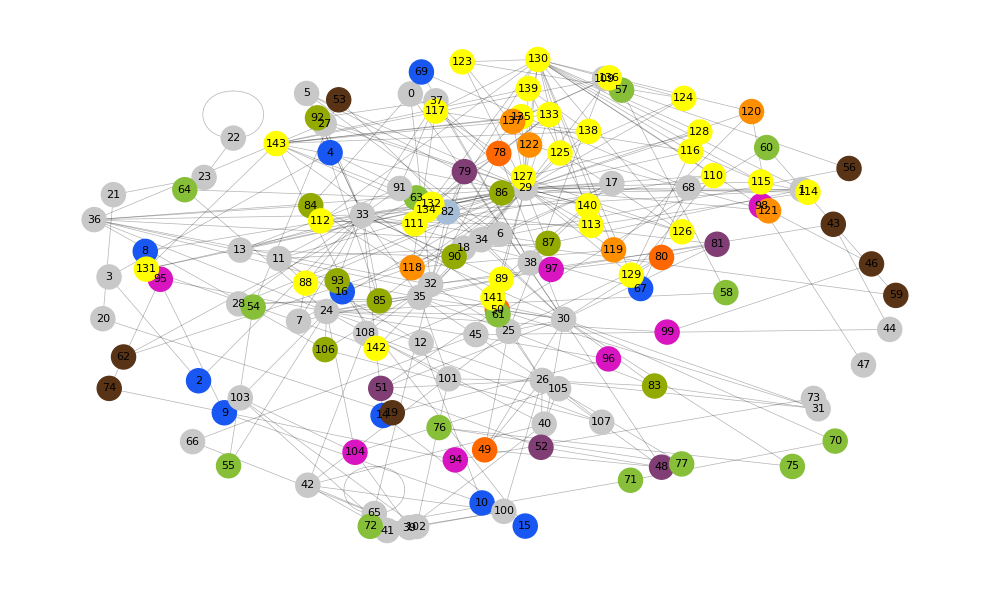

In [13]:
adj_graph = brep_encoder.push_face_adjacency_graph()
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = adj_graph
n = G.number_of_nodes()

pos = nx.spring_layout(adj_graph, k=0.5, seed=42)

nodes = list(G.nodes())  # order used for coloring
to01 = lambda rgb: tuple(c/255 for c in rgb)

node_colors = [to01(color_palette.get_color(predictions[i])) for i in range(len(nodes))]

plt.figure(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, arrows=False)
nx.draw_networkx_nodes(G, pos, node_size=300, node_color=node_colors)
nx.draw_networkx_labels(G, pos, labels={n: str(n) for n in nodes}, font_size=8)

plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
face_index = 58 # in green
neighbor_faces = set(adj_graph.successors(face_index)) | set(adj_graph.predecessors(face_index))
print(neighbor_faces)

{24, 57}


In [15]:
print("face types:", face_types_descr[face_types[58]], "-> face area:", face_areas[58])
face_sampling_coordinates = face_discretization[58,:,:3]
face_sampling_normals = face_discretization[58,:,3:6]
print("some face_sampling_coordinates" ,  face_sampling_coordinates[:3])
print("some face_sampling_normals" ,  face_sampling_normals[:3])

face types: Cylinder -> face area: 633.13
some face_sampling_coordinates [[-0.13335    0.01905   -0.1762125]
 [-0.13335    0.02159   -0.1762125]
 [-0.13335    0.02413   -0.1762125]]
some face_sampling_normals [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [16]:
viewer.terminate()